# Financial Forecasting Frontier: Distributed Machine Learning

## Exploratory Data Analysis (EDA) with Apache Spark

### Project Objective

To perform exploratory data analysis on banking customer data using Apache Spark and identify patterns, trends, and insights that can support banking decision-making.

### Project Goal

The goal of this notebook is to utilize Spark DataFrames and distributed processing techniques to analyze customer demographics, financial characteristics, loan behavior, marketing campaign performance, and subscription outcomes.

### Dataset Overview

The dataset contains 4,521 banking customer records with demographic information, account balances, loan details, contact history, campaign information, and term deposit subscription status.

### Technologies Used

* Apache Spark (PySpark)
* Spark SQL
* Python
* Pandas
* Matplotlib
* Google Colab

### Business Problem

Banks collect large volumes of customer data that must be analyzed efficiently to understand customer behavior, improve marketing effectiveness, identify risk patterns, and increase subscription conversion rates.

### GitHub Repository

GitHub Link: [Link](https://github.com/Aks18had/Financial-Forecasting-Frontier-Distributed-ML)

### Dataset Source

Dataset provided by Alma Better


In [ ]:
# Mount Google Drive  Mounting the G Drive for dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load Dataset

DATA_PATH = "/content/drive/MyDrive/Distributed_ML_Project/bank.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Question 1: Data Loading and Basic Inspection

### Objective
Load the banking dataset into a Spark DataFrame and perform initial inspection to understand the structure and characteristics of the data.

In [ ]:
# Install PySpark

!pip install pyspark -q

In [ ]:
# Create Spark Session

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Banking_EDA") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [ ]:
# Load Dataset into Spark DataFrame

spark_df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True
)

print("Dataset Loaded into Spark DataFrame")

Dataset Loaded into Spark DataFrame


In [ ]:
# First Few Rows

spark_df.show(5)

+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown|  5|  may|     22

In [ ]:
# Schema

spark_df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [ ]:
# Summary Statistics

spark_df.describe().show()

+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|summary|               age|    job| marital|education|default|           balance|housing|loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|   y|
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|  count|              4521|   4521|    4521|     4521|   4521|              4521|   4521|4521|    4521|              4521| 4521|              4521|              4521|              4521|              4521|    4521|4521|
|   mean| 41.17009511170095|   NULL|    NULL|     NULL|   NULL|1422.6578190665782|   NULL|NULL|    NULL|15.9152842291528

## Question 2: Data Filtering and Column Operations

### Objective
Perform filtering operations and create additional derived columns for further analysis.

In [ ]:
# Filter Clients with Balance Greater Than 1000

high_balance_df = spark_df.filter(
    spark_df.balance > 1000
)

print("Clients with Balance > 1000")
high_balance_df.show(5)

Clients with Balance > 1000
+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|       job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30|unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|  services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35|management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30|management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 39|  services|married|secondary|     no|   9374|    yes|  no| unkno

In [ ]:
from pyspark.sql.functions import when, col

quarter_df = spark_df.withColumn(
    "quarter",
    when(col("month").isin("jan","feb","mar"), "Q1")
    .when(col("month").isin("apr","may","jun"), "Q2")
    .when(col("month").isin("jul","aug","sep"), "Q3")
    .otherwise("Q4")
)

quarter_df.select(
    "month",
    "quarter"
).show(10)

+-----+-------+
|month|quarter|
+-----+-------+
|  oct|     Q4|
|  may|     Q2|
|  apr|     Q2|
|  jun|     Q2|
|  may|     Q2|
|  feb|     Q1|
|  may|     Q2|
|  may|     Q2|
|  may|     Q2|
|  apr|     Q2|
+-----+-------+
only showing top 10 rows


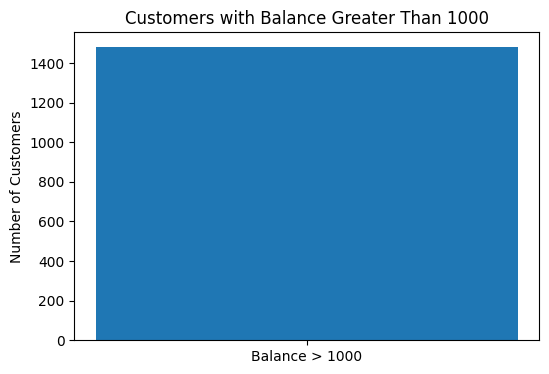

In [ ]:
# Convert to Pandas for Visualization

high_balance_pd = high_balance_df.toPandas()

plt.figure(figsize=(6,4))

plt.bar(
    ["Balance > 1000"],
    [len(high_balance_pd)]
)

plt.title("Customers with Balance Greater Than 1000")
plt.ylabel("Number of Customers")

plt.show()

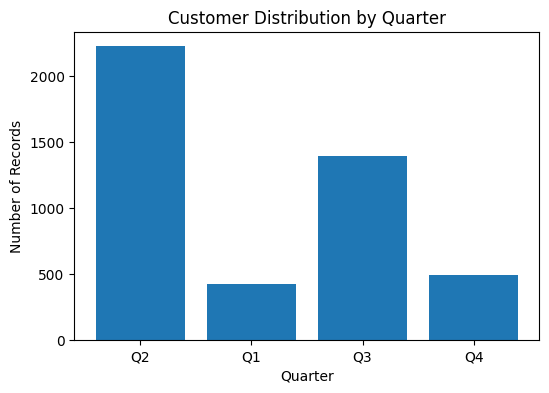

In [ ]:
quarter_counts = (
    quarter_df.groupBy("quarter")
    .count()
    .toPandas()
)

plt.figure(figsize=(6,4))

plt.bar(
    quarter_counts["quarter"],
    quarter_counts["count"]
)

plt.title("Customer Distribution by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Number of Records")

plt.show()

### Observation

A subset of customers with balances greater than 1000 was identified for focused financial analysis. A new quarter feature was also created to support seasonal trend analysis. The quarter distribution indicates how customer interactions are spread across different periods of the year, which can be useful when evaluating campaign effectiveness and customer engagement patterns.

## Question 3(A): Average Balance and Median Age by Job Category

### Objective
Analyze financial and demographic characteristics across different job categories.

In [ ]:
from pyspark.sql.functions import avg, expr

job_analysis = spark_df.groupBy("job").agg(
    avg("balance").alias("Average_Balance"),
    expr("percentile(age, 0.5)").alias("Median_Age")
)

job_analysis.show()

+-------------+------------------+----------+
|          job|   Average_Balance|Median_Age|
+-------------+------------------+----------+
|   management|1766.9287925696594|      38.0|
|      retired| 2319.191304347826|      59.0|
|      unknown|1501.7105263157894|      49.5|
|self-employed|1392.4098360655737|      40.0|
|      student|1543.8214285714287|      26.0|
|  blue-collar| 1085.161733615222|      39.0|
| entrepreneur|          1645.125|      41.0|
|       admin.|  1226.73640167364|      38.0|
|   technician|     1330.99609375|      38.0|
|     services|1103.9568345323742|      37.0|
|    housemaid|2083.8035714285716|      49.0|
|   unemployed|       1089.421875|      41.0|
+-------------+------------------+----------+



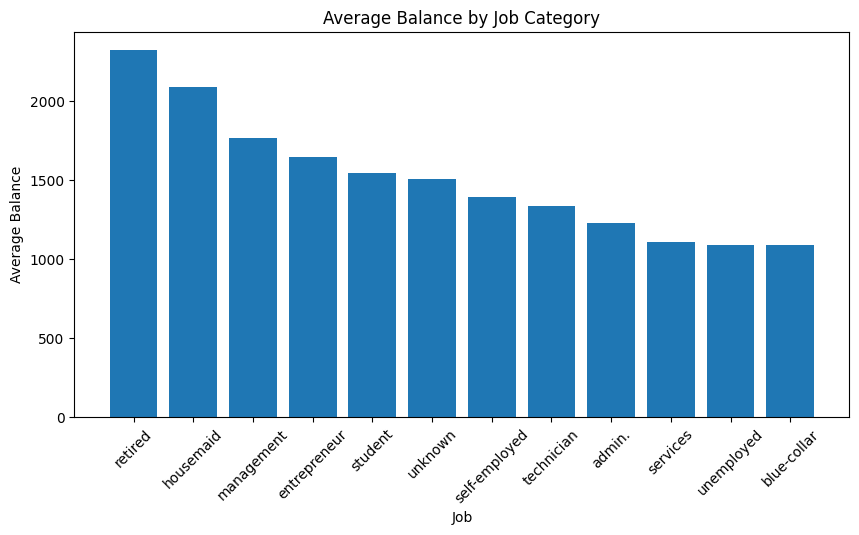

In [ ]:
job_pd = job_analysis.toPandas()

job_pd = job_pd.sort_values(
    "Average_Balance",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    job_pd["job"],
    job_pd["Average_Balance"]
)

plt.title("Average Balance by Job Category")
plt.xlabel("Job")
plt.ylabel("Average Balance")

plt.xticks(rotation=45)

plt.show()

### Observation

Average account balances vary across professions. Certain job categories maintain significantly higher balances, indicating stronger financial capacity and potential opportunities for premium banking products.

## Question 3(B): Subscription Count by Marital Status

### Objective
Analyze how term deposit subscriptions vary across different marital status groups.

In [ ]:
subscription_marital = (
    spark_df
    .filter(col("y") == "yes")
    .groupBy("marital")
    .count()
)

subscription_marital.show()

+--------+-----+
| marital|count|
+--------+-----+
|divorced|   77|
| married|  277|
|  single|  167|
+--------+-----+



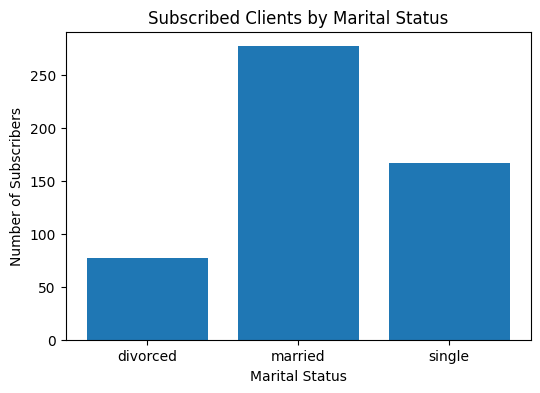

In [ ]:
subscription_pd = subscription_marital.toPandas()

plt.figure(figsize=(6,4))

plt.bar(
    subscription_pd["marital"],
    subscription_pd["count"]
)

plt.title("Subscribed Clients by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Subscribers")

plt.show()

### Observation

Subscription behavior differs across marital groups. Understanding these differences helps banks identify customer segments that may be more responsive to term deposit marketing campaigns.

In [ ]:
job_analysis.orderBy(
    col("Average_Balance").desc()
).show(5)

+------------+------------------+----------+
|         job|   Average_Balance|Median_Age|
+------------+------------------+----------+
|     retired| 2319.191304347826|      59.0|
|   housemaid|2083.8035714285716|      49.0|
|  management|1766.9287925696594|      38.0|
|entrepreneur|          1645.125|      41.0|
|     student|1543.8214285714287|      26.0|
+------------+------------------+----------+
only showing top 5 rows


## Question 4: User Defined Function (UDF)

### Objective
Create a custom age group category using a Spark User Defined Function (UDF) to segment customers into meaningful demographic groups.

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
def age_group(age):
    if age < 30:
        return "<30"
    elif age <= 60:
        return "30-60"
    else:
        return ">60"

age_group_udf = udf(age_group, StringType())

In [ ]:
age_group_df = spark_df.withColumn(
    "age_group",
    age_group_udf(col("age"))
)

age_group_df.select(
    "age",
    "age_group"
).show(10)

+---+---------+
|age|age_group|
+---+---------+
| 30|    30-60|
| 33|    30-60|
| 35|    30-60|
| 30|    30-60|
| 59|    30-60|
| 35|    30-60|
| 36|    30-60|
| 39|    30-60|
| 41|    30-60|
| 43|    30-60|
+---+---------+
only showing top 10 rows


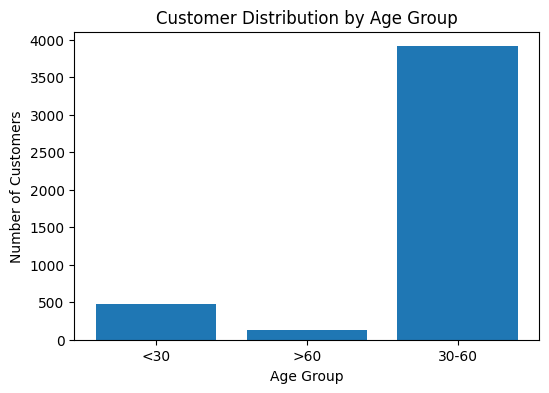

In [ ]:
age_group_counts = (
    age_group_df
    .groupBy("age_group")
    .count()
    .toPandas()
)

plt.figure(figsize=(6,4))

plt.bar(
    age_group_counts["age_group"],
    age_group_counts["count"]
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
age_group_df.groupBy(
    "age_group"
).count().show()

+---------+-----+
|age_group|count|
+---------+-----+
|      <30|  482|
|      >60|  127|
|    30-60| 3912|
+---------+-----+



### Observation

A custom UDF was used to classify customers into age groups. The distribution reveals the dominant age segments within the banking customer base and provides a foundation for customer segmentation and targeted marketing strategies.

## Question 5: Subscription Rate by Education Level

### Objective
Analyze how term deposit subscription rates vary across different education levels and identify customer segments with higher subscription tendencies.

In [ ]:
from pyspark.sql.functions import when, avg

education_subscription = (
    spark_df
    .withColumn(
        "subscription_flag",
        when(col("y") == "yes", 1).otherwise(0)
    )
    .groupBy("education")
    .agg(
        avg("subscription_flag").alias("subscription_rate")
    )
)

education_subscription.show()

+---------+-------------------+
|education|  subscription_rate|
+---------+-------------------+
|  unknown|0.10160427807486631|
| tertiary|0.14296296296296296|
|secondary|  0.106244579358196|
|  primary| 0.0943952802359882|
+---------+-------------------+



In [ ]:
education_pd = education_subscription.toPandas()

education_pd["subscription_rate"] = (
    education_pd["subscription_rate"] * 100
)

education_pd

,education,subscription_rate
0,unknown,10.160428
1,tertiary,14.296296
2,secondary,10.624458
3,primary,9.439528


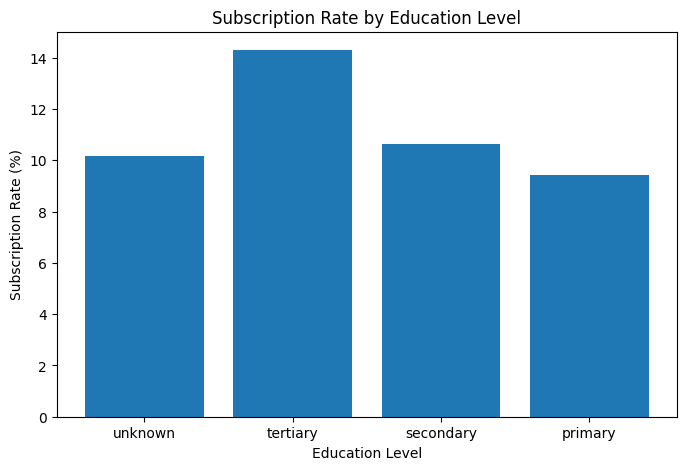

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    education_pd["education"],
    education_pd["subscription_rate"]
)

plt.title("Subscription Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Subscription Rate (%)")

plt.show()

In [ ]:
education_pd.sort_values( # The Insight Cell
    "subscription_rate",
    ascending=False
)

,education,subscription_rate
1,tertiary,14.296296
2,secondary,10.624458
0,unknown,10.160428
3,primary,9.439528


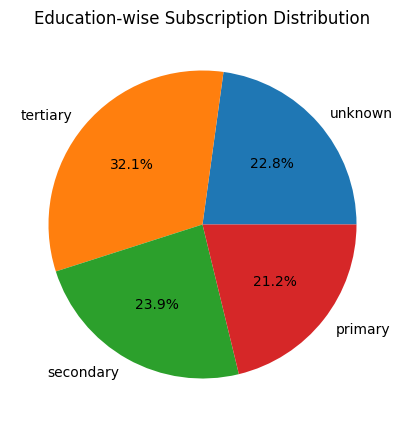

In [ ]:
plt.figure(figsize=(8,5)) # Pie Chart

plt.pie(
    education_pd["subscription_rate"],
    labels=education_pd["education"],
    autopct="%1.1f%%"
)

plt.title("Education-wise Subscription Distribution")

plt.show()

### Observation

Subscription rates vary across education levels, indicating that educational background may influence customer investment decisions. Identifying high-conversion education segments can help banks design more targeted marketing campaigns and financial products.

## Question 6: Top 3 Professions with Highest Default Rate

### Objective
Analyze loan default behavior across professions and identify job categories with the highest default rates.

In [ ]:
from pyspark.sql.functions import avg, when

default_rate_job = (
    spark_df
    .withColumn(
        "default_flag",
        when(col("default") == "yes", 1).otherwise(0)
    )
    .groupBy("job")
    .agg(
        avg("default_flag").alias("default_rate")
    )
)

In [ ]:
default_rate_pd = default_rate_job.toPandas()

default_rate_pd["default_rate"] = (
    default_rate_pd["default_rate"] * 100
)

top3_default = default_rate_pd.sort_values(
    "default_rate",
    ascending=False
).head(3)

top3_default

,job,default_rate
6,entrepreneur,4.166667
11,unemployed,2.343750
3,self-employed,2.185792


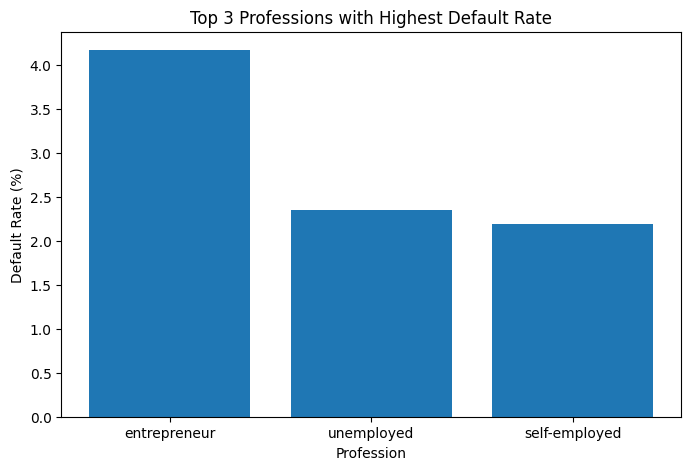

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    top3_default["job"],
    top3_default["default_rate"]
)

plt.title("Top 3 Professions with Highest Default Rate")
plt.xlabel("Profession")
plt.ylabel("Default Rate (%)")

plt.show()

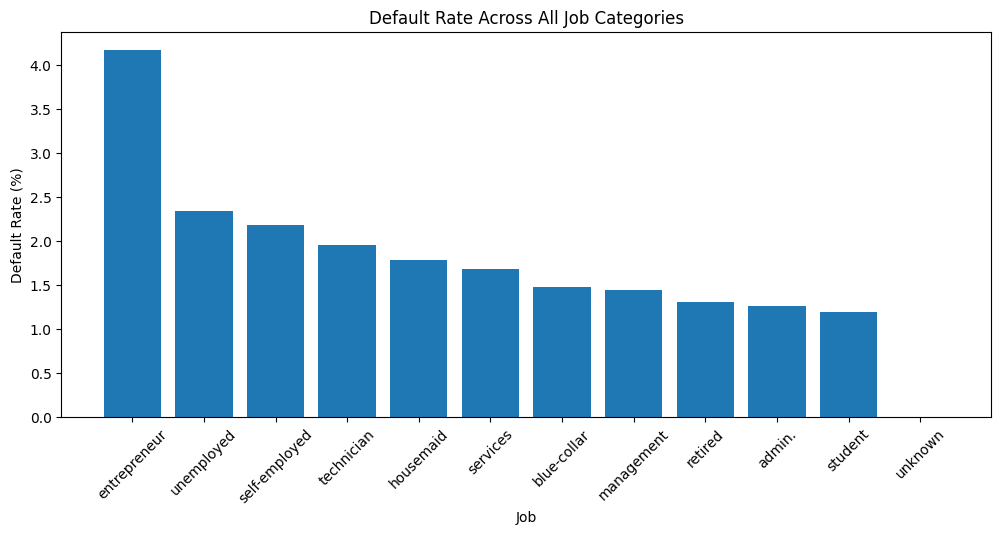

In [ ]:
default_rate_pd_sorted = default_rate_pd.sort_values(
    "default_rate",
    ascending=False
)

plt.figure(figsize=(12,5))

plt.bar(
    default_rate_pd_sorted["job"],
    default_rate_pd_sorted["default_rate"]
)

plt.title("Default Rate Across All Job Categories")
plt.xlabel("Job")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Observation

Loan default rates differ across professions, indicating varying financial risk levels among customer segments. Identifying high-risk occupations can support credit assessment strategies and improve lending decisions.

## Question 7: String Manipulation and Date Functions

### Objective
Perform string transformation operations to create new derived attributes and standardize text values.

In [ ]:
from pyspark.sql.functions import concat_ws, upper

In [ ]:
string_df = spark_df.withColumn(
    "job_marital",
    concat_ws("_", col("job"), col("marital"))
)

string_df.select(
    "job",
    "marital",
    "job_marital"
).show(10)

+-------------+-------+--------------------+
|          job|marital|         job_marital|
+-------------+-------+--------------------+
|   unemployed|married|  unemployed_married|
|     services|married|    services_married|
|   management| single|   management_single|
|   management|married|  management_married|
|  blue-collar|married| blue-collar_married|
|   management| single|   management_single|
|self-employed|married|self-employed_mar...|
|   technician|married|  technician_married|
| entrepreneur|married|entrepreneur_married|
|     services|married|    services_married|
+-------------+-------+--------------------+
only showing top 10 rows


In [ ]:
contact_df = string_df.withColumn(
    "contact_upper",
    upper(col("contact"))
)

contact_df.select(
    "contact",
    "contact_upper"
).show(10)

+--------+-------------+
| contact|contact_upper|
+--------+-------------+
|cellular|     CELLULAR|
|cellular|     CELLULAR|
|cellular|     CELLULAR|
| unknown|      UNKNOWN|
| unknown|      UNKNOWN|
|cellular|     CELLULAR|
|cellular|     CELLULAR|
|cellular|     CELLULAR|
| unknown|      UNKNOWN|
|cellular|     CELLULAR|
+--------+-------------+
only showing top 10 rows


In [ ]:
contact_df.select(
    "job",
    "marital",
    "job_marital",
    "contact",
    "contact_upper"
).show(15, truncate=False)

+-------------+-------+---------------------+--------+-------------+
|job          |marital|job_marital          |contact |contact_upper|
+-------------+-------+---------------------+--------+-------------+
|unemployed   |married|unemployed_married   |cellular|CELLULAR     |
|services     |married|services_married     |cellular|CELLULAR     |
|management   |single |management_single    |cellular|CELLULAR     |
|management   |married|management_married   |unknown |UNKNOWN      |
|blue-collar  |married|blue-collar_married  |unknown |UNKNOWN      |
|management   |single |management_single    |cellular|CELLULAR     |
|self-employed|married|self-employed_married|cellular|CELLULAR     |
|technician   |married|technician_married   |cellular|CELLULAR     |
|entrepreneur |married|entrepreneur_married |unknown |UNKNOWN      |
|services     |married|services_married     |cellular|CELLULAR     |
|services     |married|services_married     |unknown |UNKNOWN      |
|admin.       |married|admin._marr

### Observation

String manipulation techniques were applied to generate new descriptive features and standardize categorical values. These transformations improve data consistency and can support future analytical and machine learning workflows.

## Question 8(A): Most Contacted Month and Campaign Success Rate

### Objective
Identify the month with the highest customer contact volume and evaluate the corresponding subscription success rate.

In [ ]:
from pyspark.sql.functions import count, avg, when

month_analysis = (
    spark_df
    .withColumn(
        "success_flag",
        when(col("y") == "yes", 1).otherwise(0)
    )
    .groupBy("month")
    .agg(
        count("*").alias("total_contacts"),
        avg("success_flag").alias("success_rate")
    )
)

month_analysis.show()

+-----+--------------+-------------------+
|month|total_contacts|       success_rate|
+-----+--------------+-------------------+
|  jun|           531|0.10357815442561205|
|  aug|           633|0.12480252764612954|
|  may|          1398|0.06652360515021459|
|  feb|           222|0.17117117117117117|
|  sep|            52| 0.3269230769230769|
|  mar|            49|0.42857142857142855|
|  oct|            80|             0.4625|
|  jul|           706|0.08640226628895184|
|  nov|           389|0.10025706940874037|
|  apr|           293|0.19112627986348124|
|  dec|            20|               0.45|
|  jan|           148|0.10810810810810811|
+-----+--------------+-------------------+



In [ ]:
month_pd = month_analysis.toPandas()

month_pd["success_rate"] = (
    month_pd["success_rate"] * 100
)

month_pd.sort_values(
    "total_contacts",
    ascending=False
).head(1)

,month,total_contacts,success_rate
2,may,1398,6.652361


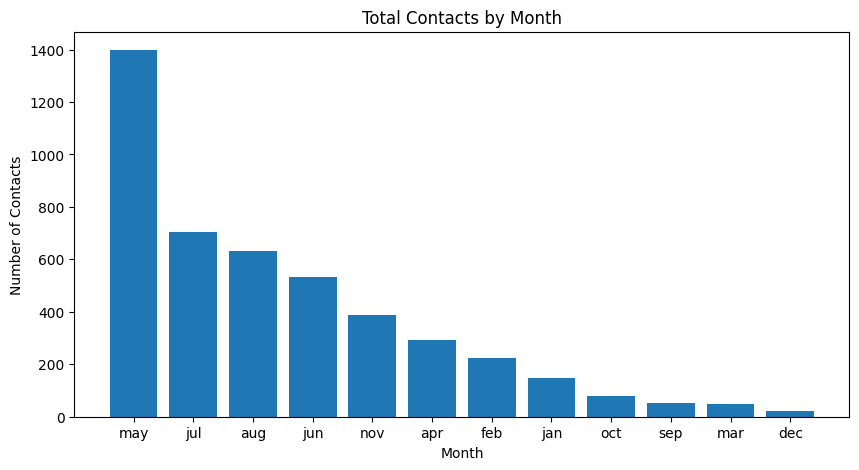

In [ ]:
plt.figure(figsize=(10,5))

month_pd_sorted = month_pd.sort_values(
    "total_contacts",
    ascending=False
)

plt.bar(
    month_pd_sorted["month"],
    month_pd_sorted["total_contacts"]
)

plt.title("Total Contacts by Month")
plt.xlabel("Month")
plt.ylabel("Number of Contacts")

plt.show()

### Observation

The analysis identifies the month with the highest customer outreach activity and evaluates campaign effectiveness through subscription success rates. This helps assess whether increased contact volume translates into higher conversion rates.

## Question 8(B): Contact Duration Comparison

### Objective
Compare customer interaction duration between subscribers and non-subscribers.

In [ ]:
duration_analysis = (
    spark_df
    .groupBy("y")
    .agg(
        avg("duration").alias("average_duration")
    )
)

duration_analysis.show()

+---+-----------------+
|  y| average_duration|
+---+-----------------+
| no|         226.3475|
|yes|552.7428023032629|
+---+-----------------+



In [ ]:
duration_pd = duration_analysis.toPandas()

duration_pd

,y,average_duration
0,no,226.347500
1,yes,552.742802


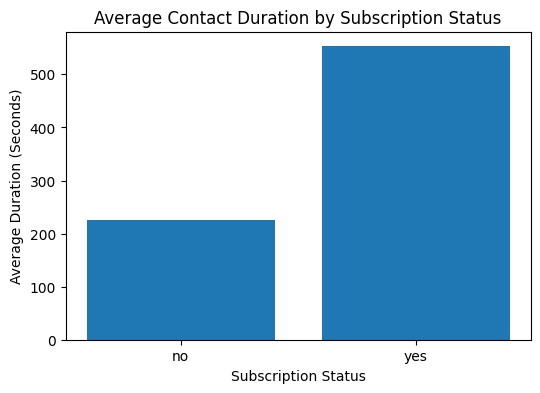

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    duration_pd["y"],
    duration_pd["average_duration"]
)

plt.title("Average Contact Duration by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Duration (Seconds)")

plt.show()

In [ ]:
duration_pd.sort_values(
    "average_duration",
    ascending=False
)

,y,average_duration
1,yes,552.742802
0,no,226.347500


### Observation

The comparison reveals whether longer customer interactions are associated with successful term deposit subscriptions. Contact duration is often an important indicator of customer engagement and campaign effectiveness.

## Question 9: Correlation Analysis

### Objective
Analyze the relationship between customer age and account balance using correlation analysis.

In [ ]:
correlation = spark_df.stat.corr(
    "age",
    "balance"
)

print(
    f"Correlation between Age and Balance: {correlation:.4f}"
)

Correlation between Age and Balance: 0.0838


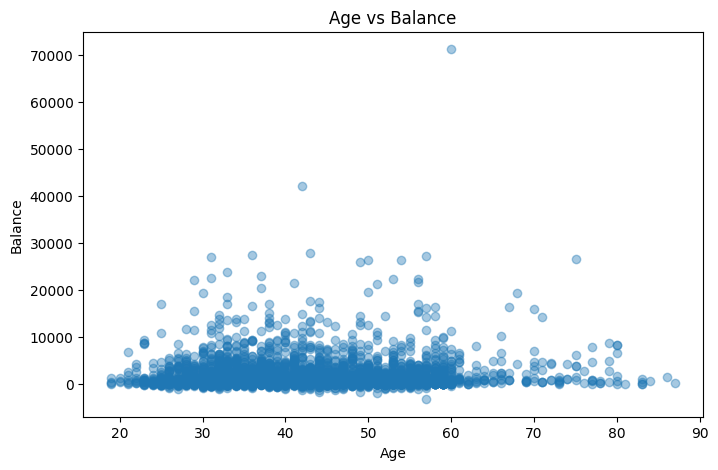

In [ ]:
age_balance_pd = (
    spark_df
    .select("age", "balance")
    .toPandas()
)

plt.figure(figsize=(8,5))

plt.scatter(
    age_balance_pd["age"],
    age_balance_pd["balance"],
    alpha=0.4
)

plt.title("Age vs Balance")
plt.xlabel("Age")
plt.ylabel("Balance")

plt.show()

### Observation

Correlation analysis was used to measure the relationship between age and account balance. The resulting coefficient indicates the strength and direction of the relationship, while the scatter plot visually represents the distribution of customer balances across age groups.

## Question 10 (a) : Spark SQL Analysis

### Objective
Perform analytical queries using Spark SQL to demonstrate SQL-based data exploration on distributed datasets.

In [ ]:
age_group_df.createOrReplaceTempView(
    "bank_data"
)

In [ ]:
spark.sql("""
SELECT
    age_group,
    ROUND(AVG(balance),2) AS avg_balance
FROM bank_data
GROUP BY age_group
ORDER BY avg_balance DESC
""").show()

+---------+-----------+
|age_group|avg_balance|
+---------+-----------+
|      >60|    2676.35|
|    30-60|    1426.88|
|      <30|     1058.1|
+---------+-----------+



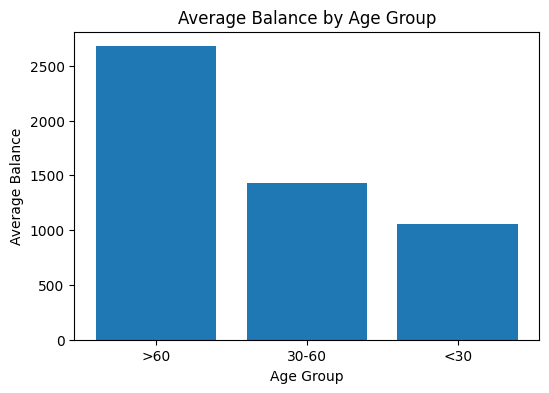

In [ ]:
sql_age_balance = spark.sql("""
SELECT
    age_group,
    ROUND(AVG(balance),2) AS avg_balance
FROM bank_data
GROUP BY age_group
ORDER BY avg_balance DESC
""")

sql_age_pd = sql_age_balance.toPandas()

plt.figure(figsize=(6,4))

plt.bar(
    sql_age_pd["age_group"],
    sql_age_pd["avg_balance"]
)

plt.title("Average Balance by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Balance")

plt.show()

### Observation

Spark SQL enables efficient querying of distributed datasets using familiar SQL syntax. The analysis identified customer segments with higher average balances and highlighted the most common professions represented in the banking dataset.

## Question 10 (b): Data Visualization

### Objective
Convert the Spark DataFrame to a Pandas DataFrame and visualize the distribution of clients across job categories.

In [ ]:
job_count_pd = (
    spark_df
    .groupBy("job")
    .count()
    .toPandas()
)

job_count_pd.head()

,job,count
0,management,969
1,retired,230
2,unknown,38
3,self-employed,183
4,student,84


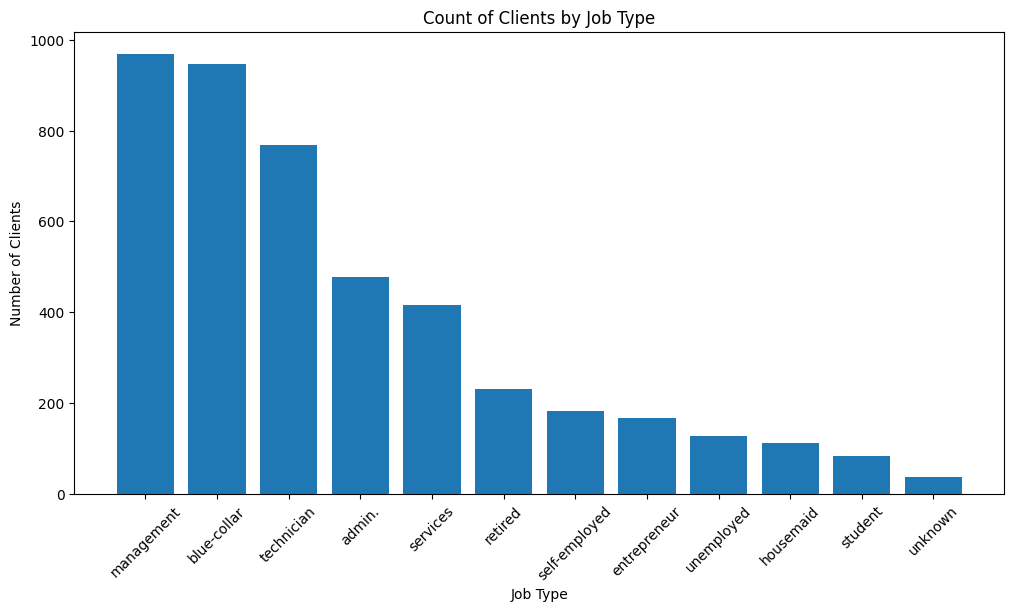

In [ ]:
plt.figure(figsize=(12,6))

job_count_pd = job_count_pd.sort_values(
    "count",
    ascending=False
)

plt.bar(
    job_count_pd["job"],
    job_count_pd["count"]
)

plt.title("Count of Clients by Job Type")
plt.xlabel("Job Type")
plt.ylabel("Number of Clients")

plt.xticks(rotation=45)

plt.show()

### Observation

The visualization highlights the distribution of customers across job categories. Certain professions represent a significantly larger portion of the customer base, indicating key customer segments for banking products and marketing campaigns.

## Q11: Exploring Loan Defaults

### Objective
Analyze the proportion of clients with and without credit defaults and visualize their distribution.

In [ ]:
default_analysis = (
    spark_df
    .groupBy("default")
    .count()
)

default_analysis.show()

+-------+-----+
|default|count|
+-------+-----+
|     no| 4445|
|    yes|   76|
+-------+-----+



In [ ]:
default_pd = default_analysis.toPandas()

default_pd

,default,count
0,no,4445
1,yes,76


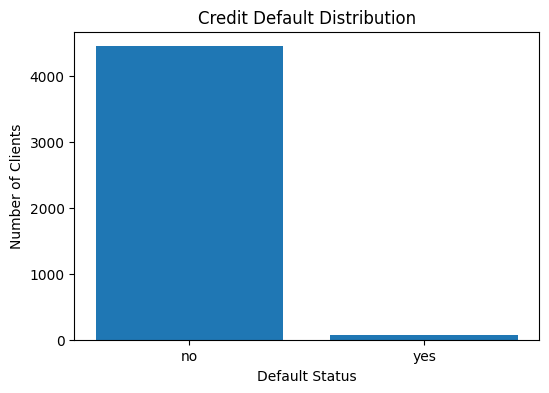

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    default_pd["default"],
    default_pd["count"]
)

plt.title("Credit Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Clients")

plt.show()

### Observation

The dataset contains a very small proportion of customers with credit defaults. This indicates a highly imbalanced default distribution and suggests that most customers maintain good credit standing.

## Q12: Contact Method Analysis

### Objective
Analyze the effectiveness of different customer contact methods and identify which communication channel achieves the highest subscription success rate.

In [ ]:
from pyspark.sql.functions import avg, when

contact_analysis = (
    spark_df
    .withColumn(
        "success_flag",
        when(col("y") == "yes", 1).otherwise(0)
    )
    .groupBy("contact")
    .agg(
        avg("success_flag").alias("success_rate")
    )
)

contact_analysis.show()

+---------+-------------------+
|  contact|       success_rate|
+---------+-------------------+
|  unknown|0.04607250755287009|
| cellular|  0.143646408839779|
|telephone| 0.1461794019933555|
+---------+-------------------+



In [ ]:
contact_pd = contact_analysis.toPandas()

contact_pd["success_rate"] = (
    contact_pd["success_rate"] * 100
)

contact_pd.sort_values(
    "success_rate",
    ascending=False
)

,contact,success_rate
2,telephone,14.617940
1,cellular,14.364641
0,unknown,4.607251


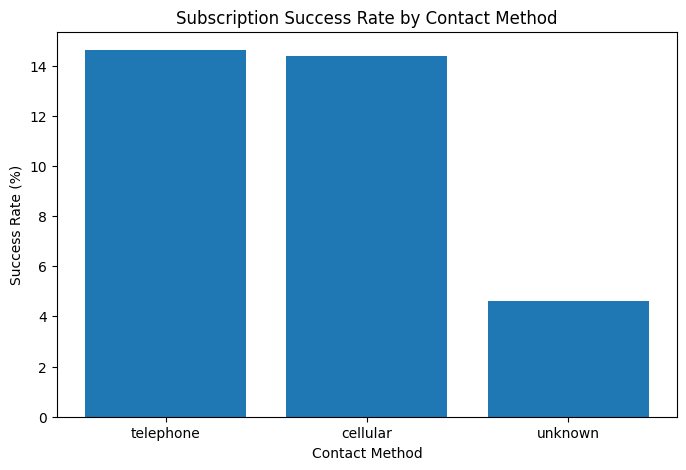

In [ ]:
plt.figure(figsize=(8,5))

contact_pd = contact_pd.sort_values(
    "success_rate",
    ascending=False
)

plt.bar(
    contact_pd["contact"],
    contact_pd["success_rate"]
)

plt.title("Subscription Success Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Success Rate (%)")

plt.show()

### Observation

The effectiveness of customer communication channels varies significantly. Identifying the highest-performing contact method helps banks optimize marketing campaigns, improve customer engagement, and increase subscription conversion rates.

# Key Findings

* Customer balances vary considerably across different professions, indicating differences in financial capacity and banking behavior.
* Subscription rates differ across education levels, suggesting that customer demographics influence investment decisions.
* Contact duration shows a strong relationship with successful term deposit subscriptions, highlighting the importance of customer engagement.
* Credit defaults are relatively rare within the dataset, resulting in a highly imbalanced default distribution.
* Certain contact methods achieve higher subscription success rates, demonstrating the importance of communication strategy in banking campaigns.
* Spark SQL enabled efficient querying and analysis of customer segments, balances, and demographic patterns.

# Learnings

* Learned how to perform distributed exploratory data analysis using Apache Spark.
* Applied Spark DataFrame operations such as filtering, aggregation, transformations, and grouping.
* Implemented User Defined Functions (UDFs) for customer segmentation.
* Used Spark SQL to perform analytical queries on distributed datasets.
* Developed practical experience in converting Spark DataFrames to Pandas DataFrames for visualization and reporting.
* Gained insights into customer demographics, loan behavior, subscription patterns, and campaign effectiveness.

# Conclusion

This notebook demonstrated the application of Apache Spark for large-scale exploratory data analysis in the banking domain. Multiple analytical techniques were applied to understand customer characteristics, financial behavior, loan patterns, campaign performance, and subscription outcomes. The results illustrate how distributed data processing frameworks can efficiently transform raw banking data into meaningful business insights that support data-driven decision-making.
